# TSN Scheduling with OF-FF Defragmentation (Corrected)

**Problem Fixed**: Streams now occupy ONE link at a time (TSN-realistic), not multiple links simultaneously.

**Key Principles**:
1. Each frame travels sequentially through its path
2. Frame occupies each link for exactly `frameDuration` microseconds  
3. Between hops, frame experiences: propagation delay + processing delay
4. Conflict detection checks individual links (not global time)
5. OF-FF reallocates oldest streams using First-Fit with proper per-hop timing

In [1]:
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
from matplotlib.patches import Rectangle
import copy

## Section 1: Load and Validate TSN Network Data

In [6]:
# Load network JSON
with open("scenario.json") as f:
    network_data = json.load(f)

print("=== NETWORK TOPOLOGY ===")
print("Nodes:", [n['name'] for n in network_data['nodes']])
print("\nLinks:")
for link in network_data['links']:
    print(f"  {link['sourceNode']}.{link['sourcePort']} -> {link['destNode']}.{link['destPort']} (prop_delay={link['propDelay']}µs)")

print("\nStreams:")
for stream in network_data['streams']:
    print(f"  {stream['name']}: path={stream['pathLists'][0]}, offset={stream['offset']}, age={stream['age']}, frameDuration={stream.get('frameDuration', 20000)}µs")

=== NETWORK TOPOLOGY ===
Nodes: ['H1', 'H2', 'H3', 'S1', 'S2', 'S3']

Links:
  H1.P1 -> S1.P1 (prop_delay=1µs)
  S1.P2 -> S2.P1 (prop_delay=1µs)
  S1.P1 -> S3.P2 (prop_delay=1µs)
  S2.P2 -> H2.P1 (prop_delay=1µs)
  S3.P2 -> H3.P1 (prop_delay=1µs)

Streams:
  Stream1: path=['H1', 'S1', 'S2', 'H2'], offset=0, age=50, frameDuration=20000µs
  Stream2: path=['H1', 'S1', 'S3', 'H3'], offset=26, age=20, frameDuration=20000µs


## Section 2: Build Correct Per-Link Schedules with TSN Timing

For each stream, calculate when it occupies each link in its path by accounting for:
- **Frame duration**: Time frame spends on each link (e.g., 20000 µs)
- **Propagation delay**: Link transmission delay (from JSON)
- **Processing delay**: Switch processing at intermediate hops (from JSON)

In [7]:
def get_link(network_data, src_node, dst_node):
    """Get link between two nodes (finds any available path)"""
    return next((l for l in network_data['links'] 
                if l['sourceNode'] == src_node and l['destNode'] == dst_node), None)

def compute_stream_hops(stream, network_data):
    """
    Compute CORRECT TSN timing: when frame occupies each link in path.
    Path is list of node names: ['H1', 'S1', 'S2', 'H2']
    """
    hops = []
    current_time = stream['offset']
    frame_duration = stream.get('frameDuration', 20000)
    path = stream['pathLists'][0]
    
    for hop_idx in range(len(path) - 1):
        src_node_name = path[hop_idx]
        dst_node_name = path[hop_idx + 1]
        
        # Find the link between these nodes
        link = get_link(network_data, src_node_name, dst_node_name)
        if not link:
            print(f"WARNING: No link found from {src_node_name} to {dst_node_name}")
            continue
        
        link_name = f"{src_node_name} -> {dst_node_name}"
        
        # THIS hop: frame on this link
        hops.append({
            'link_name': link_name,
            'start': current_time,
            'duration': frame_duration,
            'end': current_time + frame_duration
        })
        
        # Get delays for computing NEXT hop start time
        prop_delay = link['propDelay'] if link else 0
        
        dst_node = get_node(network_data, dst_node_name)
        proc_delay = dst_node['procDelay'] if (dst_node and dst_node['type'] == 'switch') else 0
        
        # NEXT hop starts after: frame leaves + propagation + processing
        current_time = current_time + frame_duration + prop_delay + proc_delay
    
    return hops

# Test on first stream
stream1_hops = compute_stream_hops(network_data['streams'][0], network_data)
print("Stream1 hop timing:")
for hop in stream1_hops:
    print(f"  {hop['link_name']}: [{hop['start']} - {hop['end']}] µs")

Stream1 hop timing:
  H1 -> S1: [0 - 20000] µs
  S1 -> S2: [20006 - 40006] µs
  S2 -> H2: [40012 - 60012] µs


In [8]:
def build_link_schedules(network_data):
    """
    Create per-link schedule dictionary:
    link_name -> list of {'stream': name, 'start': t1, 'duration': d}
    """
    # Initialize all links
    link_schedules = {}
    for link in network_data['links']:
        link_name = f"{link['sourceNode']} -> {link['destNode']}"
        link_schedules[link_name] = []
    
    # Add each stream's hops
    for stream in network_data['streams']:
        hops = compute_stream_hops(stream, network_data)
        for hop in hops:
            link_schedules[hop['link_name']].append({
                'stream': stream['name'],
                'start': hop['start'],
                'duration': hop['duration']
            })
    
    return link_schedules

# Build initial schedule
link_schedules_before = build_link_schedules(network_data)
print(f"Built schedules for {len(link_schedules_before)} links")
print(f"Total frames allocated: {sum(len(v) for v in link_schedules_before.values())}")

Built schedules for 5 links
Total frames allocated: 6


## Section 3: Implement Conflict Detection Across Links

In [9]:
def can_allocate_stream(stream, offset, network_data, link_schedules):
    """
    Check if stream can fit at given offset without conflicts.
    Returns: (True, hops) if feasible, (False, None) if conflict exists
    
    Conflict occurs when two frames overlap on THE SAME LINK.
    Frames on different links can exist at same time (stream is in-flight).
    """
    test_hops = []
    current_time = offset
    frame_duration = stream.get('frameDuration', 20000)
    path = stream['pathLists'][0]
    
    for hop_idx in range(len(path) - 1):
        src_node_name = path[hop_idx]
        dst_node_name = path[hop_idx + 1]
        
        link_name = f"{src_node_name} -> {dst_node_name}"
        
        # Check for conflict on THIS SPECIFIC LINK
        for existing in link_schedules.get(link_name, []):
            # Overlap if: current window intersects with existing window
            if not (current_time + frame_duration <= existing['start'] or 
                    current_time >= existing['start'] + existing['duration']):
                return (False, None)  # Conflict!
        
        test_hops.append({
            'link_name': link_name,
            'start': current_time,
            'duration': frame_duration
        })
        
        # Compute next hop's start time (same as in compute_stream_hops)
        link = get_link(network_data, src_node_name, dst_node_name)
        prop_delay = link['propDelay'] if link else 0
        dst_node = get_node(network_data, dst_node_name)
        proc_delay = dst_node['procDelay'] if (dst_node and dst_node['type'] == 'switch') else 0
        current_time = current_time + frame_duration + prop_delay + proc_delay
    
    return (True, test_hops)

# Test conflict detection
can_fit, test_hops = can_allocate_stream(network_data['streams'][1], 100, network_data, link_schedules_before)
print(f"Can allocate Stream2 at offset 100? {can_fit}")

Can allocate Stream2 at offset 100? False


## Section 4: Apply OF-FF Heuristic with Proper Per-Hop Timing

In [10]:
def of_ff_heuristic(network_data_orig, num_reallocations=1):
    """
    Oldest-First, First-Fit heuristic:
    1. Sort streams by age (oldest first)
    2. Remove N oldest streams from all links
    3. Re-allocate them using First-Fit starting from offset 0
    """
    network_data = copy.deepcopy(network_data_orig)
    link_schedules = build_link_schedules(network_data)
    
    # Sort by age (oldest first)
    streams_sorted = sorted(network_data['streams'], key=lambda s: s['age'], reverse=True)
    to_reallocate = streams_sorted[:num_reallocations]
    
    print(f"OF-FF: Reallocating {[s['name'] for s in to_reallocate]} (oldest first)")
    print()
    
    for stream in to_reallocate:
        # Remove this stream from all links
        for link_name in link_schedules:
            link_schedules[link_name] = [e for e in link_schedules[link_name] 
                                        if e['stream'] != stream['name']]
        
        # Find earliest feasible offset using First-Fit
        found = False
        best_offset = None
        
        # Try offsets from 0, incrementing by 1 µs
        for test_offset in range(0, 200000, 1):
            can_fit, hops = can_allocate_stream(stream, test_offset, network_data, link_schedules)
            if can_fit:
                best_offset = test_offset
                # Allocate at this offset
                stream['offset'] = test_offset
                for hop in hops:
                    link_schedules[hop['link_name']].append({
                        'stream': stream['name'],
                        'start': hop['start'],
                        'duration': hop['duration']
                    })
                print(f"  {stream['name']}: reallocated from {stream['offset']} → {best_offset} µs")
                found = True
                break
        
        if not found:
            print(f"  {stream['name']}: WARNING - could not reallocate!")
    
    return network_data, link_schedules

# Apply OF-FF
network_data_after, link_schedules_after = of_ff_heuristic(network_data, num_reallocations=1)

OF-FF: Reallocating ['Stream1'] (oldest first)

  Stream1: reallocated from 20026 → 20026 µs


## Section 5: Visualize Corrected Schedule

Visualize before and after with per-stream colors. Each link shows only frames currently occupying it.

Stream colors: {'Stream1': '#1f77b4', 'Stream2': '#ff7f0e'}


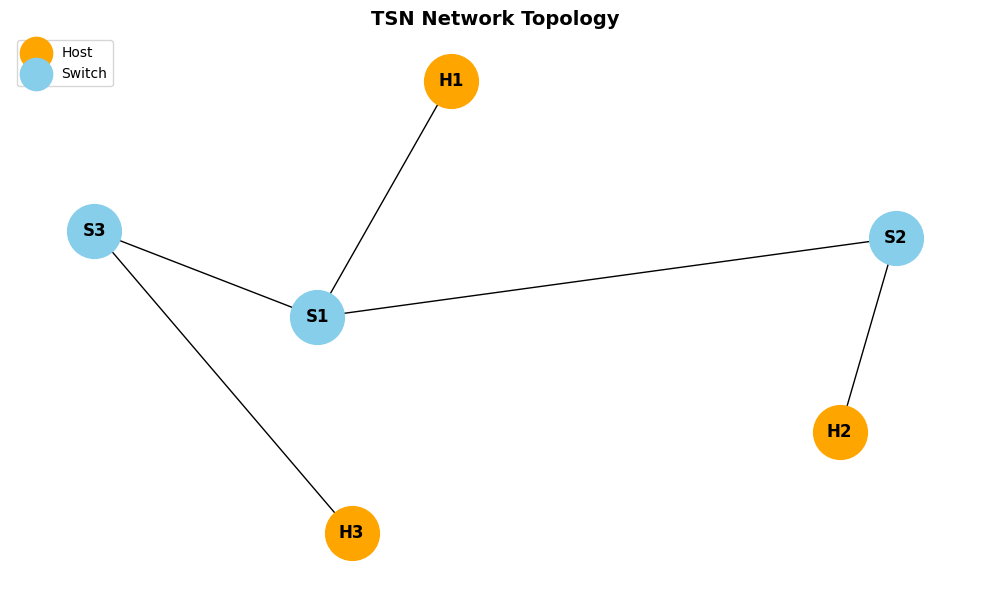

In [11]:
# Create color palette for streams
stream_colors = {}
all_streams = set()
for entries in link_schedules_before.values():
    for entry in entries:
        all_streams.add(entry['stream'])

colors_palette = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())
for i, stream_name in enumerate(sorted(all_streams)):
    stream_colors[stream_name] = colors_palette[i % len(colors_palette)]

print(f"Stream colors: {stream_colors}")

# Visualize network topology
G = nx.DiGraph()
for node in network_data['nodes']:
    G.add_node(node['name'], type=node['type'])
for link in network_data['links']:
    G.add_edge(link['sourceNode'], link['destNode'])

pos = nx.spring_layout(G, seed=42, k=2)
plt.figure(figsize=(10, 6))

host_nodes = [n['name'] for n in network_data['nodes'] if n['type'] == 'host']
switch_nodes = [n['name'] for n in network_data['nodes'] if n['type'] == 'switch']

nx.draw_networkx_nodes(G, pos, nodelist=host_nodes, node_color='orange', node_size=1500, label='Host')
nx.draw_networkx_nodes(G, pos, nodelist=switch_nodes, node_color='skyblue', node_size=1500, label='Switch')
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=20)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

plt.title("TSN Network Topology", fontsize=14, fontweight='bold')
plt.legend(scatterpoints=1, markerscale=0.6, loc='upper left')
plt.axis('off')
plt.tight_layout()
plt.show()

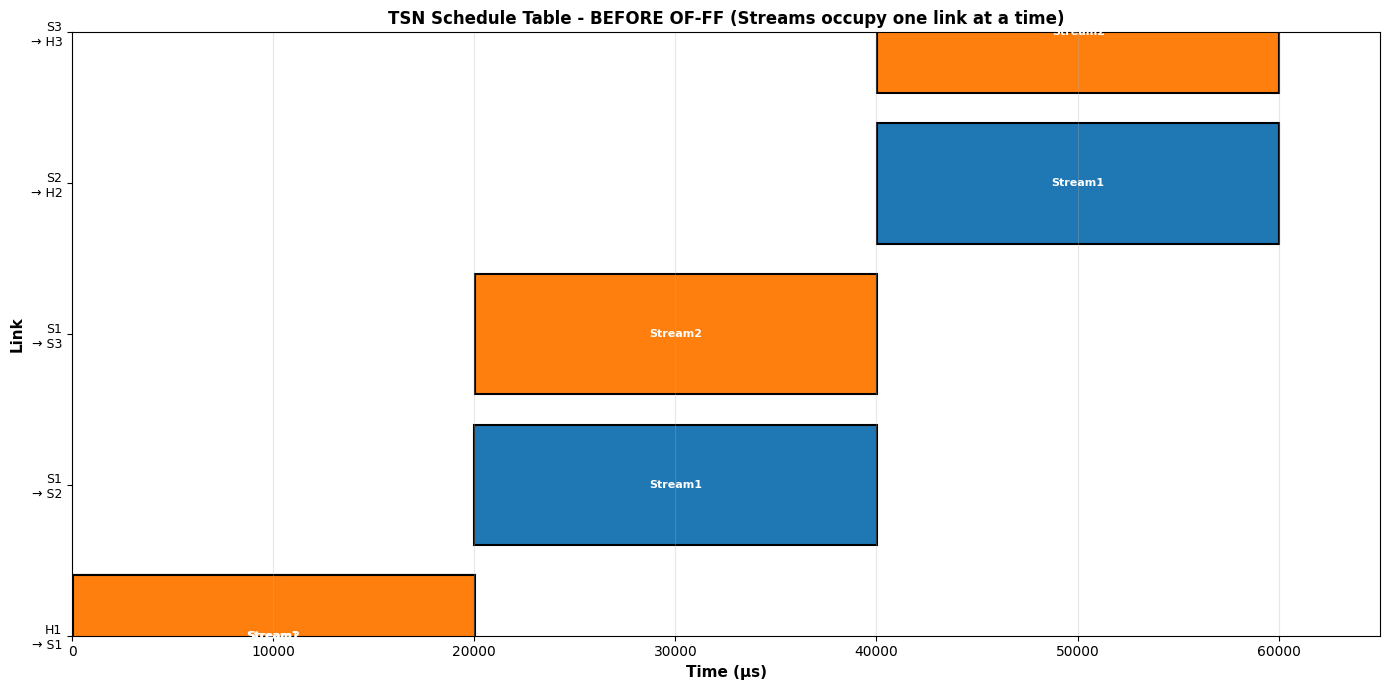

In [12]:
# Visualize BEFORE OF-FF
fig, ax = plt.subplots(figsize=(14, 7))

links_list = sorted(link_schedules_before.keys())
y_ticks = list(range(len(links_list)))
y_labels = [link.replace(' -> ', '\n→ ') for link in links_list]

max_time = 0
for i, link_name in enumerate(links_list):
    for entry in link_schedules_before[link_name]:
        rect = Rectangle(
            (entry['start'], i - 0.4),
            entry['duration'],
            0.8,
            facecolor=stream_colors[entry['stream']],
            edgecolor='black',
            linewidth=1.5
        )
        ax.add_patch(rect)
        ax.text(entry['start'] + entry['duration']/2, i, entry['stream'], 
               ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        max_time = max(max_time, entry['start'] + entry['duration'])

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlabel('Time (µs)', fontsize=11, fontweight='bold')
ax.set_ylabel('Link', fontsize=11, fontweight='bold')
ax.set_title('TSN Schedule Table - BEFORE OF-FF (Streams occupy one link at a time)', fontsize=12, fontweight='bold')
ax.set_xlim(0, max_time + 5000)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

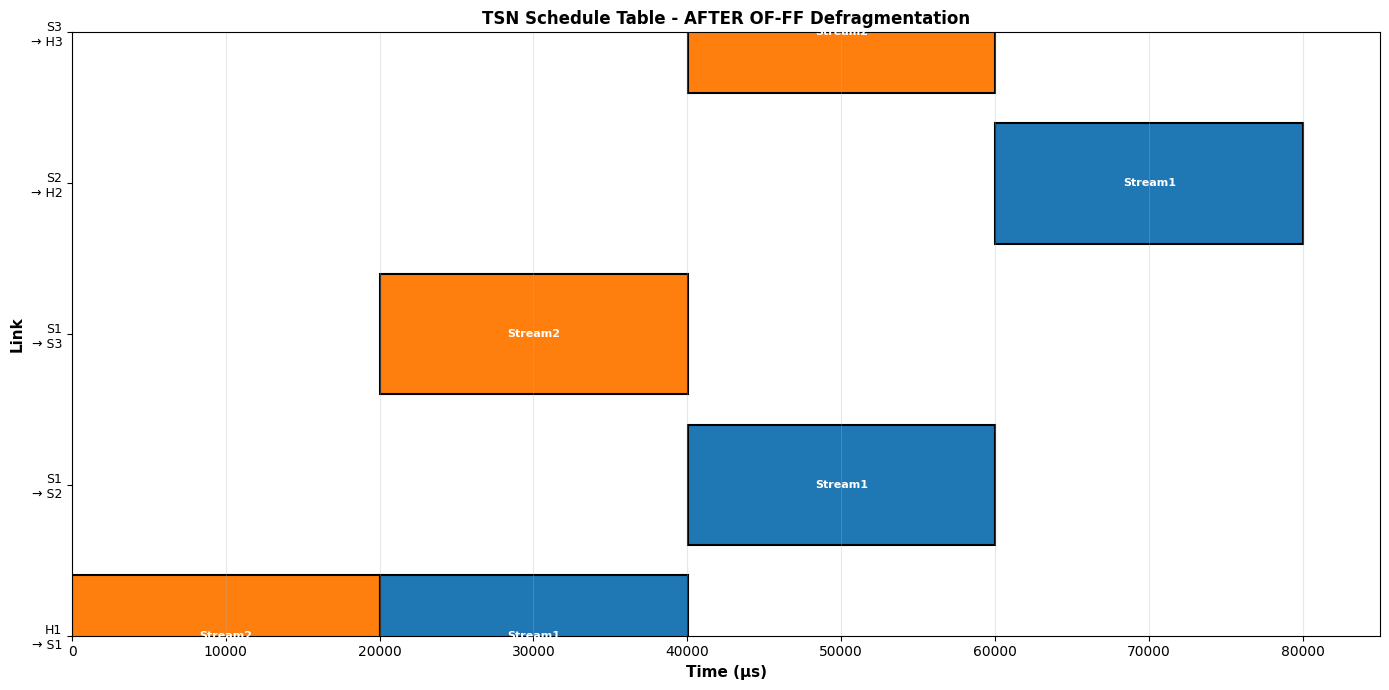

In [13]:
# Visualize AFTER OF-FF
fig, ax = plt.subplots(figsize=(14, 7))

links_list = sorted(link_schedules_after.keys())
y_ticks = list(range(len(links_list)))
y_labels = [link.replace(' -> ', '\n→ ') for link in links_list]

max_time_after = 0
for i, link_name in enumerate(links_list):
    for entry in link_schedules_after[link_name]:
        rect = Rectangle(
            (entry['start'], i - 0.4),
            entry['duration'],
            0.8,
            facecolor=stream_colors[entry['stream']],
            edgecolor='black',
            linewidth=1.5
        )
        ax.add_patch(rect)
        ax.text(entry['start'] + entry['duration']/2, i, entry['stream'], 
               ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        max_time_after = max(max_time_after, entry['start'] + entry['duration'])

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlabel('Time (µs)', fontsize=11, fontweight='bold')
ax.set_ylabel('Link', fontsize=11, fontweight='bold')
ax.set_title('TSN Schedule Table - AFTER OF-FF Defragmentation', fontsize=12, fontweight='bold')
ax.set_xlim(0, max(max_time, max_time_after) + 5000)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 6: Validate Stream Latency Constraints

In [14]:
def compute_stream_latency(stream, network_data):
    """
    Calculate end-to-end latency for a stream.
    Latency = sum of (frame_duration + prop_delay + proc_delay) for each hop
    """
    hops = compute_stream_hops(stream, network_data)
    path = stream['pathLists'][0]
    frame_duration = stream.get('frameDuration', 20000)
    
    latency = 0
    for i, hop in enumerate(hops):
        latency += hop['duration']  # Frame duration
        
        # Add delays between hops
        if i < len(hops) - 1:  # Not the last hop
            src_node_name = path[i]
            dst_node_name = path[i + 1]
            
            link = get_link(network_data, src_node_name, dst_node_name)
            prop_delay = link['propDelay'] if link else 0
            
            dst_node = get_node(network_data, dst_node_name)
            proc_delay = dst_node['procDelay'] if (dst_node and dst_node['type'] == 'switch') else 0
            
            latency += prop_delay + proc_delay
    
    return latency

print("=== LATENCY VALIDATION (BEFORE) ===")
for stream in network_data['streams']:
    latency = compute_stream_latency(stream, network_data)
    max_latency = stream['maxLatency']
    status = "✓ OK" if latency <= max_latency else "✗ EXCEEDED"
    print(f"{stream['name']}: {latency} µs / max {max_latency} µs {status}")

print("\n=== LATENCY VALIDATION (AFTER) ===")
for stream in network_data_after['streams']:
    latency = compute_stream_latency(stream, network_data_after)
    max_latency = stream['maxLatency']
    status = "✓ OK" if latency <= max_latency else "✗ EXCEEDED"
    print(f"{stream['name']}: {latency} µs / max {max_latency} µs {status}")

=== LATENCY VALIDATION (BEFORE) ===
Stream1: 60012 µs / max 300000 µs ✓ OK
Stream2: 60012 µs / max 300000 µs ✓ OK

=== LATENCY VALIDATION (AFTER) ===
Stream1: 60012 µs / max 300000 µs ✓ OK
Stream2: 60012 µs / max 300000 µs ✓ OK
